In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from decision_tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [3]:
columns = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm", "Species"]
df = pd.read_csv("Iris.csv", usecols=columns)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 150
Total Features (columns): 5


In [5]:
#Global informations about the dataset (Columns, shape, types, missing values...) 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [6]:
#Check for Duplicate Values
duplicate_count = len(df[df.duplicated()])

if (duplicate_count>0):
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected in the data.")

Before: 150
3 Duplicate values found in the data.
After: 147


In [7]:
def check_missing_values(data: pd.DataFrame):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()

    percent = (missing / len(data)) * 100

    result = pd.DataFrame({
        "feature": missing.index,
        "missing_count": missing.values,
        "percent": percent.values
    })

    return result

print(check_missing_values(df))

Empty DataFrame
Columns: [feature, missing_count, percent]
Index: []


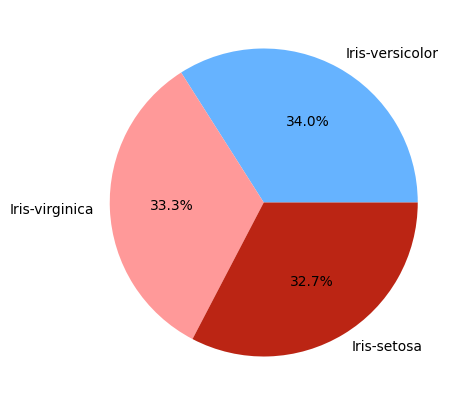

In [8]:
counts = df["Species"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(x=counts.values, labels=counts.keys(), autopct='%1.1f%%', colors=['#66b3ff', '#ff9999', '#bb2514']) 
plt.show()

In [9]:
mapping_Species = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df = df.replace(mapping_Species)

In [10]:
X, y = df.iloc[:, :-1].values, df.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_predicted = model.predict(X_test)

In [12]:
print("y_test: ", y_test[:5])
print("y_predicted: ", y_predicted[:5])

y_test:  [2 1 2 0 2]
y_predicted:  [2 1 2 0 1]


In [16]:
def accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

In [20]:
print(f"Accuracy: {accuracy(y_test, y_predicted):.3f}")

Accuracy: 0.933
